# Prediccion de Consumo Electrico con Deep Learning (LSTM)

## Proyecto academico de series temporales

Este cuaderno desarrolla un flujo completo de analisis y prediccion de consumo electrico usando redes neuronales profundas sobre el UCI Electricity Load Dataset.

### Objetivos
- Comprender la estructura temporal del consumo electrico.
- Construir un modelo LSTM para prediccion de series temporales.
- Evaluar el modelo con metricas de error (RMSE y MAE).
- Generar predicciones futuras a partir del modelo entrenado.

## 1. Introduccion

### Que es el analisis de series temporales?
El analisis de series temporales estudia datos ordenados cronologicamente para identificar patrones como tendencia, estacionalidad, ciclos y ruido.

### Que es la prediccion de consumo electrico?
Consiste en estimar el consumo futuro de energia a partir de mediciones historicas.

### RNN y LSTM en breve
- Las RNN procesan secuencias y mantienen memoria del pasado.
- Las LSTM mejoran las RNN con compuertas que aprenden dependencias de corto y largo plazo.
- Por eso, LSTM es una arquitectura muy usada en prediccion de series temporales.

In [8]:
# Si trabajas en Google Colab y te faltan librerias, descomenta la siguiente linea:
# !pip install -q numpy pandas matplotlib seaborn scikit-learn statsmodels tensorflow

import io
import zipfile
import urllib.request
import warnings
import os
import sys
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose

# Intentamos TensorFlow; si no esta disponible en esta version de Python,
# usamos Keras con backend Torch para mantener el notebook ejecutable.
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    tf.random.set_seed(42)
    dl_backend = f"tensorflow {tf.__version__}"
except ModuleNotFoundError:
    print("TensorFlow no disponible en este entorno. Instalando keras + torch...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "keras", "torch"])
    os.environ["KERAS_BACKEND"] = "torch"
    import keras
    from keras.models import Sequential
    from keras.layers import LSTM, Dense, Dropout
    from keras.callbacks import EarlyStopping
    keras.utils.set_random_seed(42)
    dl_backend = f"keras {keras.__version__} (backend torch)"

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', context='talk')
np.random.seed(42)

print('Librerias importadas correctamente')
print('Backend de Deep Learning:', dl_backend)

TensorFlow no disponible en este entorno. Instalando keras + torch...
Librerias importadas correctamente
Backend de Deep Learning: keras 3.13.2 (backend torch)


## 2. Carga del dataset

Usaremos el Electricity Load Diagrams 2011-2014 (UCI), con mediciones cada 15 minutos para multiples clientes.

Fuente:
https://archive.ics.uci.edu/ml/machine-learning-databases/00321/LD2011_2014.txt.zip

In [10]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00321/LD2011_2014.txt.zip'
print('Descargando dataset...')
response = urllib.request.urlopen(url)
zip_data = response.read()

with zipfile.ZipFile(io.BytesIO(zip_data)) as zf:
    file_name = zf.namelist()[0]
    with zf.open(file_name) as f:
        df_raw = pd.read_csv(f, sep=';', decimal=',', index_col=0, parse_dates=True)

df_raw = df_raw.dropna(axis=1, how='all').sort_index()
display(df_raw.head())
print('Dimensiones:', df_raw.shape)

Descargando dataset...


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Dimensiones: (140256, 370)


## 3. Exploracion de datos (EDA)

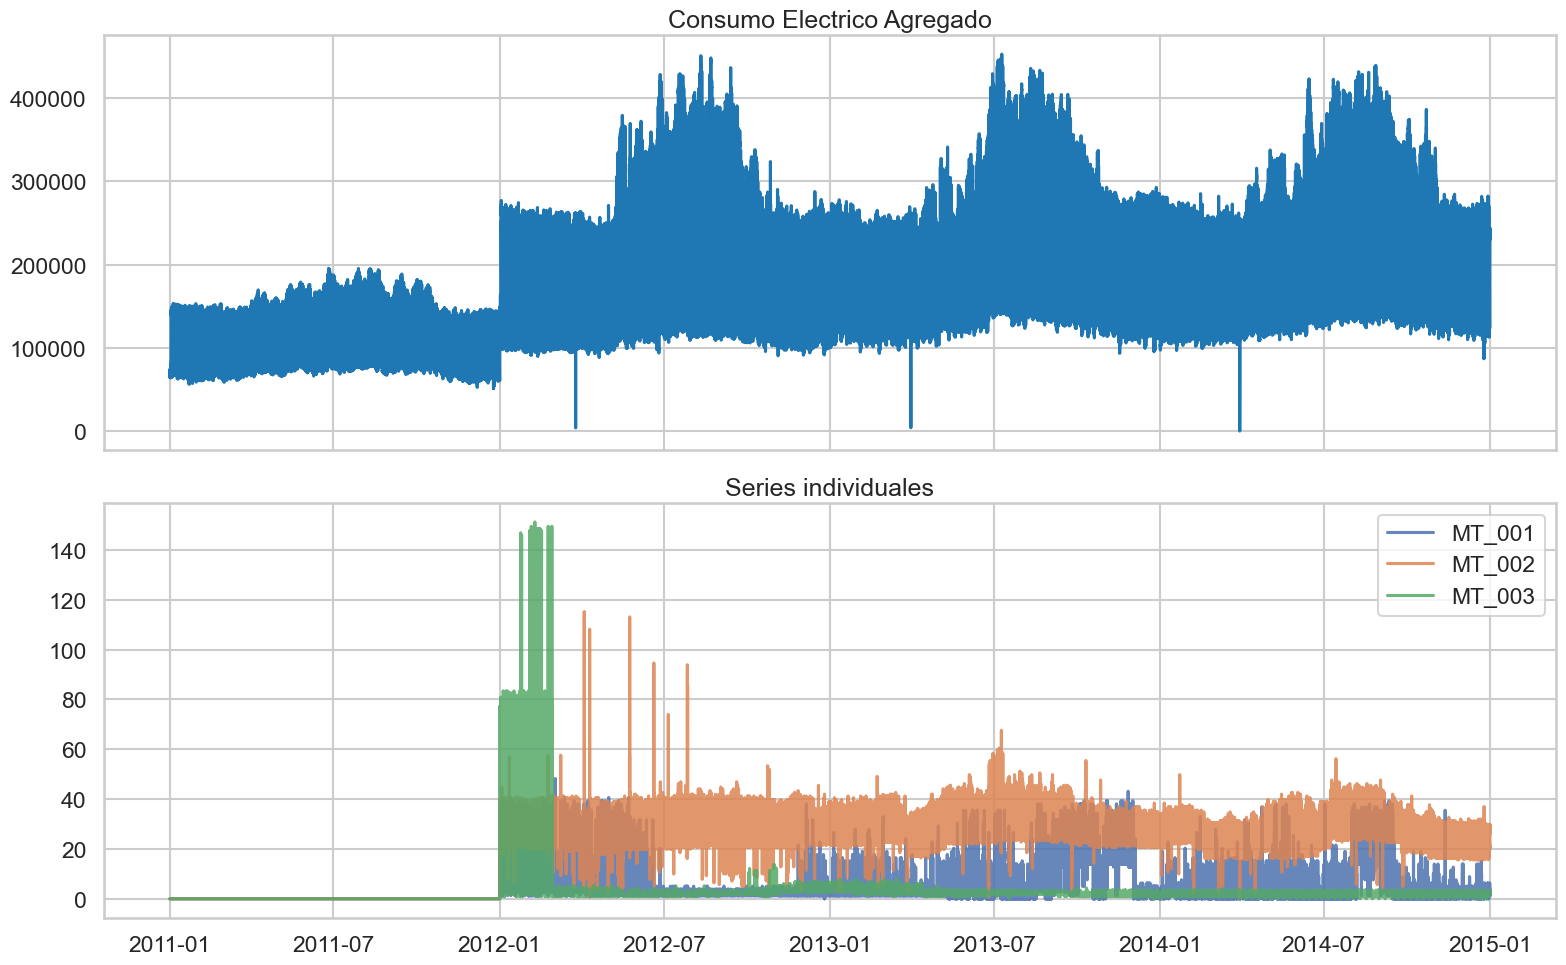

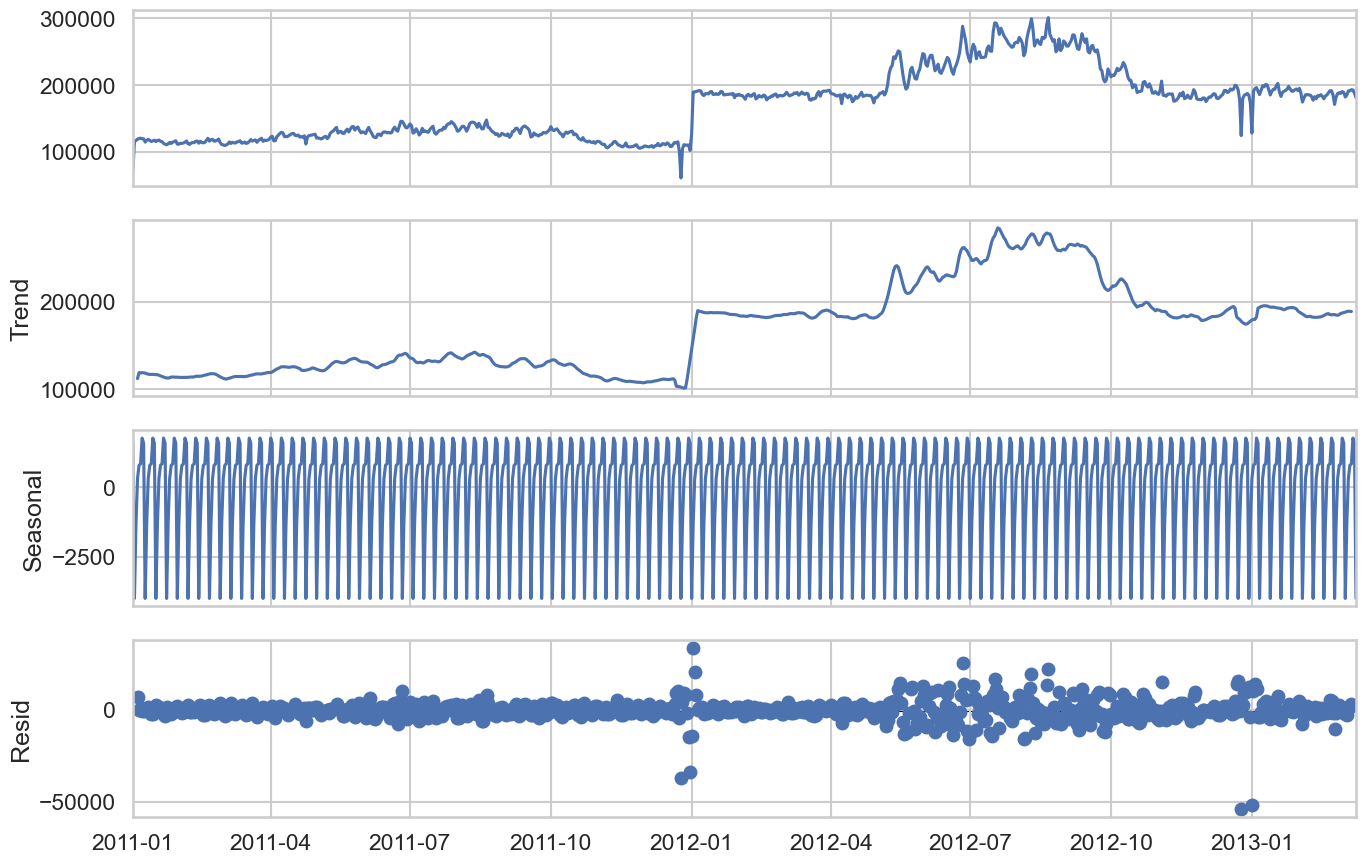

,count,mean,std,min,25%,50%,75%,max
MT_001,140256.0,3.970785,5.983965,0.0,0.000000,1.269036,2.538071,48.223350
MT_002,140256.0,20.768480,13.272415,0.0,2.844950,24.893314,29.871977,115.220484
MT_003,140256.0,2.918308,11.014456,0.0,0.000000,1.737619,1.737619,151.172893
MT_004,140256.0,82.184490,58.248392,0.0,36.585366,87.398374,115.853659,321.138211
MT_005,140256.0,37.240309,26.461327,0.0,15.853659,39.024390,54.878049,150.000000
MT_006,140256.0,141.227385,98.439984,0.0,71.428571,157.738095,205.357143,535.714286
MT_007,140256.0,4.521338,6.485684,0.0,0.565291,2.826456,4.522329,44.657999
MT_008,140256.0,191.401476,121.981187,0.0,111.111111,222.222222,279.461279,552.188552
MT_009,140256.0,39.975354,29.814595,0.0,13.986014,40.209790,57.692308,157.342657
MT_010,140256.0,42.205152,33.401251,0.0,9.677419,40.860215,61.290323,198.924731


In [11]:
total_consumption = df_raw.sum(axis=1)
sample_clients = list(df_raw.columns[:3])

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
axes[0].plot(total_consumption.index, total_consumption.values, color='tab:blue')
axes[0].set_title('Consumo Electrico Agregado')

for c in sample_clients:
    axes[1].plot(df_raw.index, df_raw[c], label=c, alpha=0.85)
axes[1].set_title('Series individuales')
axes[1].legend()
plt.tight_layout()
plt.show()

total_daily = total_consumption.resample('D').mean()
daily_for_decomp = total_daily.dropna().iloc[:800]
decomp = seasonal_decompose(daily_for_decomp, model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(14, 9)
plt.tight_layout()
plt.show()

display(df_raw.describe().T.head(10))

## 4. Preprocesamiento de datos

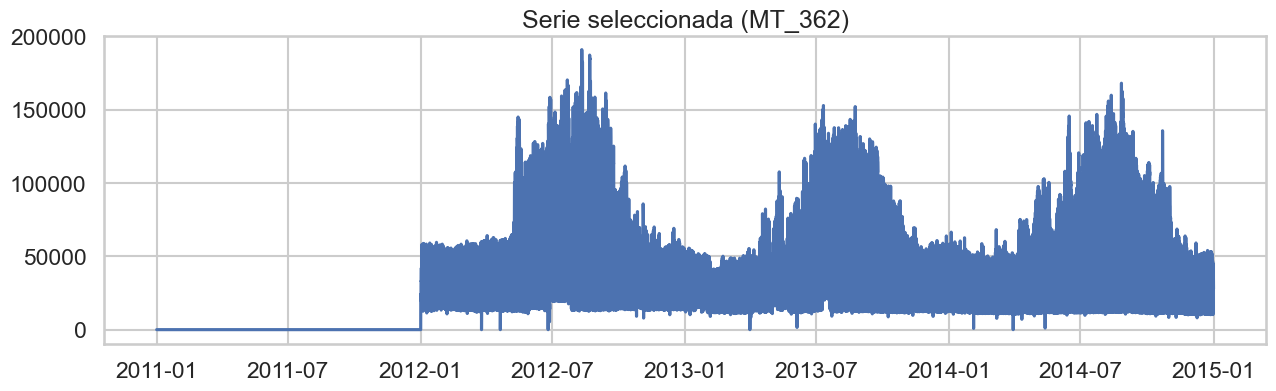

In [14]:
df_clean = df_raw.ffill().bfill()
selected_client = df_clean.mean().sort_values(ascending=False).index[0]
series_15m = df_clean[selected_client].astype(float)
series = series_15m.resample('h').mean().dropna()

scaler = MinMaxScaler(feature_range=(0, 1))
series_values = series.values.reshape(-1, 1)
series_scaled = scaler.fit_transform(series_values)

plt.figure(figsize=(15, 4))
plt.plot(series.index, series.values)
plt.title(f'Serie seleccionada ({selected_client})')
plt.show()

## 5. Creacion de ventanas temporales

In [15]:
def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 168
X_all, y_all = create_sequences(series_scaled, lookback=lookback)
print('Shape X_all:', X_all.shape)
print('Shape y_all:', y_all.shape)

Shape X_all: (34897, 168)
Shape y_all: (34897,)


## 6. Division del dataset

In [ ]:
train_size = int(len(X_all) * 0.8)
X_train, X_test = X_all[:train_size], X_all[train_size:]
y_train, y_test = y_all[:train_size], y_all[train_size:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

## 7. Construccion del modelo LSTM

In [ ]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

## 8. Entrenamiento del modelo

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Evolucion de la perdida (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 9. Evaluacion del modelo

In [ ]:
y_pred_scaled = model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_inv = scaler.inverse_transform(y_pred_scaled).ravel()

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f'RMSE: {rmse:.4f}')
print(f'MAE : {mae:.4f}')

## 10. Predicciones y visualizacion

In [ ]:
target_index = series.index[lookback:]
test_index = target_index[train_size:]
results_df = pd.DataFrame({'Real': y_test_inv, 'Predicho': y_pred_inv}, index=test_index)
display(results_df.head())

plt.figure(figsize=(16, 6))
plt.plot(results_df.index, results_df['Real'], label='Consumo Real', alpha=0.8)
plt.plot(results_df.index, results_df['Predicho'], label='Prediccion LSTM', alpha=0.8)
plt.title('Consumo real vs prediccion (test)')
plt.xlabel('Tiempo')
plt.ylabel('Consumo')
plt.legend()
plt.show()

## 11. Prediccion futura

In [ ]:
def forecast_future(model, last_window, steps):
    future_preds = []
    window = last_window.copy().reshape(-1, 1)
    for _ in range(steps):
        x_input = window.reshape(1, window.shape[0], 1)
        next_pred = model.predict(x_input, verbose=0)[0, 0]
        future_preds.append(next_pred)
        window = np.vstack([window[1:], [[next_pred]]])
    return np.array(future_preds)

future_steps = 72
last_window = series_scaled[-lookback:]
future_scaled = forecast_future(model, last_window, steps=future_steps)
future_values = scaler.inverse_transform(future_scaled.reshape(-1, 1)).ravel()

future_index = pd.date_range(start=series.index[-1] + pd.Timedelta(hours=1), periods=future_steps, freq='h')
future_df = pd.DataFrame({'Prediccion_Futura': future_values}, index=future_index)
display(future_df.head())

plt.figure(figsize=(16, 6))
plt.plot(series.index[-7*24:], series.values[-7*24:], label='Historico')
plt.plot(future_df.index, future_df['Prediccion_Futura'], label='Pronostico 72h', color='tab:red')
plt.title('Prediccion futura de consumo electrico')
plt.xlabel('Tiempo')
plt.ylabel('Consumo')
plt.legend()
plt.show()

## 12. Conclusion

- El modelo LSTM captura patrones temporales relevantes del consumo electrico.
- RMSE y MAE permiten medir el desempeno de forma interpretable.
- Como mejoras futuras: variables exogenas y modelos hibridos CNN + LSTM.